In [9]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [5]:
apartments_df = pd.read_csv("manhattan.csv")

numerical_features = ['bedrooms', 'bathrooms', 'size_sqft', 'min_to_subway', 'floor', 'building_age_yrs',
                      'no_fee', 'has_roofdeck', 'has_washer_dryer', 'has_doorman', 'has_elevator', 'has_dishwasher',
                      'has_patio', 'has_gym']

# create tensor of input features
X = torch.tensor(apartments_df[numerical_features].values, dtype=torch.float)
# create tensor of targets
y = torch.tensor(apartments_df['rent'].values, dtype=torch.float).view(-1,1)

In [6]:

X_train, X_test, y_train, y_test = train_test_split(X, y,
    train_size=0.70,
    test_size=0.30,
    random_state=2) 

In [7]:
torch.manual_seed(42)

# Define the model using nn.Sequential
model = nn.Sequential(
    nn.Linear(14, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

# MSE loss function + optimizer
loss = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 1000
for epoch in range(num_epochs):
    predictions = model(X_train) 
    MSE = loss(predictions, y_train) 
    MSE.backward()
    optimizer.step() 
    optimizer.zero_grad()
    
    # keep track of the loss during training
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], MSE Loss: {MSE.item()}')

Epoch [100/1000], MSE Loss: 2830503.0
Epoch [200/1000], MSE Loss: 2743083.75
Epoch [300/1000], MSE Loss: 2663542.25
Epoch [400/1000], MSE Loss: 2595491.0
Epoch [500/1000], MSE Loss: 2539860.75
Epoch [600/1000], MSE Loss: 2496385.0
Epoch [700/1000], MSE Loss: 2464000.0
Epoch [800/1000], MSE Loss: 2440395.25
Epoch [900/1000], MSE Loss: 2422672.5
Epoch [1000/1000], MSE Loss: 2410227.75


In [8]:
torch.save(model, 'model.pth')

In [12]:
model.eval()
with torch.no_grad():
    predictions = model(X_test)
    test_MSE = loss(predictions, y_test)

print('Test MSE is ' + str(test_MSE.item()))
print('Test Root MSE is ' + str(test_MSE.item()**(1/2)))

Test MSE is 2350587.25
Test Root MSE is 1533.162499541389


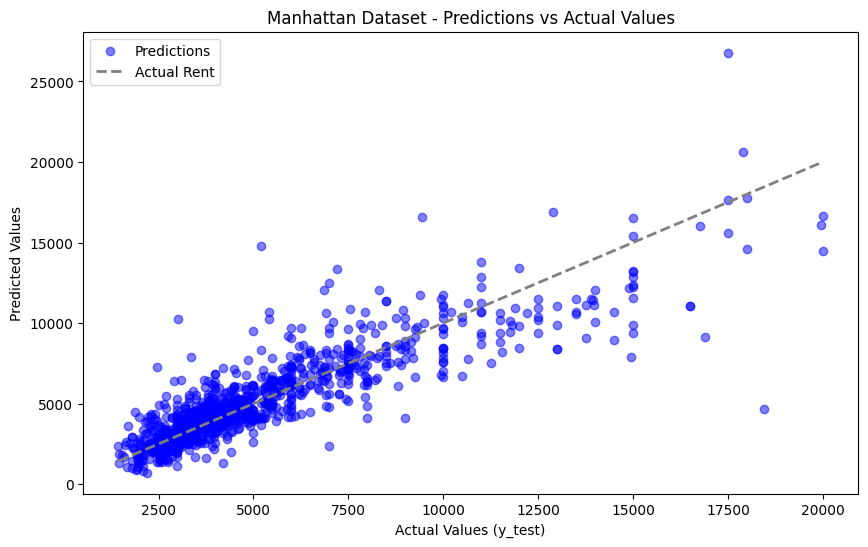

In [13]:
%matplotlib inline

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, label='Predictions', alpha=0.5, color='blue')

plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values')

plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='gray', linewidth=2,
         label="Actual Rent")
plt.legend()
plt.title('Manhattan Dataset - Predictions vs Actual Values')
plt.show()